In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## EDA

In [ ]:
#Получаем данные
df = pd.read_csv('adult.csv', encoding='windows-1252')
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


Внутри dataframe None-значения обозначены как '?', для корректной обработки данных вернем отображение None-значений

In [ ]:
df = df.replace('?', None)
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,None,103497,Some-college,10,Never-married,None,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


В колонках с числовыми признаками пропуски в данных отсутствуют

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        46043 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       46033 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   47985 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


Отсутсвует часть данных в колонках 'workclass', 'occupation', 'native-country'

In [ ]:
#Чистим датафрейм
df = df.dropna()
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


В результате очистки убрано 3620 строк, что далее может сказаться на точности выводов, сделанных на основе данных

- В данном датафрейме пропуски находились в столбцах с категориальными признаками. В таком случае, для обработки None-значений можно использовать самое часто встречающееся в соответствующем столбце (моду)

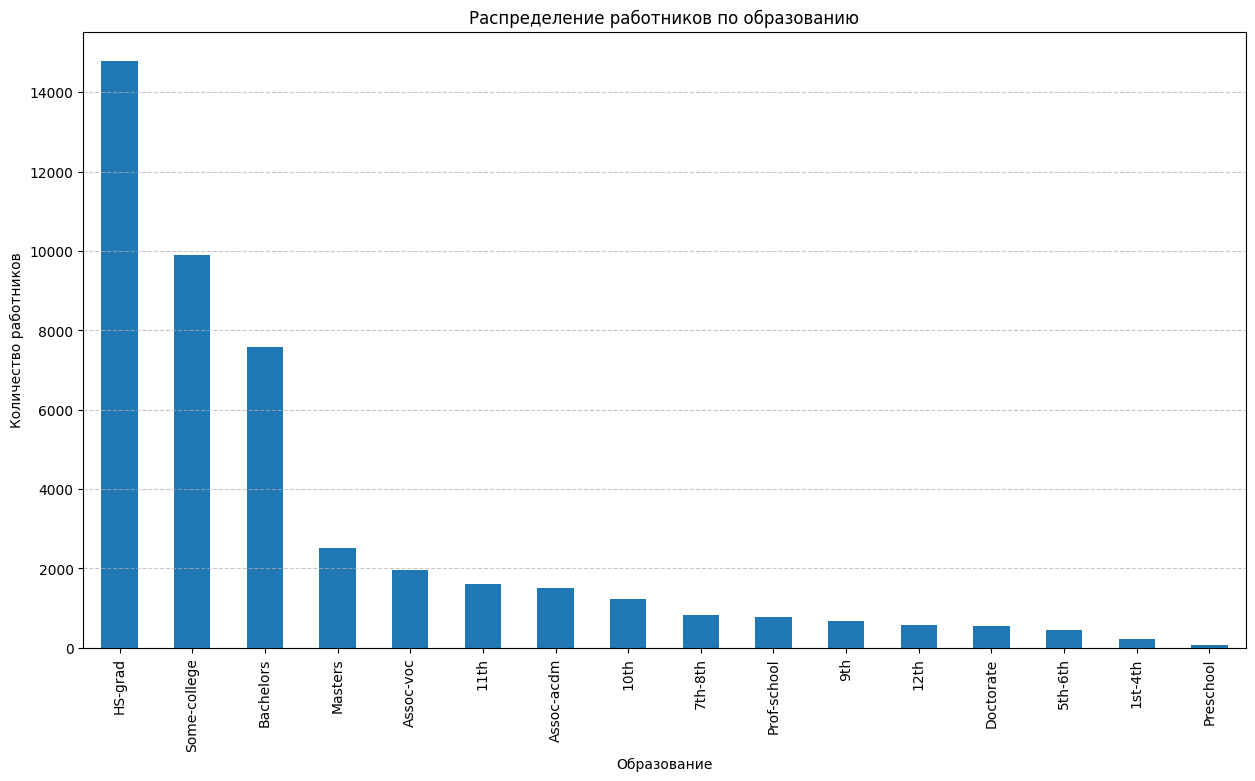

In [ ]:
counts = df['education'].value_counts()

plt.figure(figsize=(15, 8))
counts.plot.bar()
plt.title('Распределение работников по образованию')
plt.xlabel('Образование')
plt.xticks(rotation=90)
plt.ylabel('Количество работников')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

[Text(0.5, 1.0, 'Распределение работников по возрасту')]

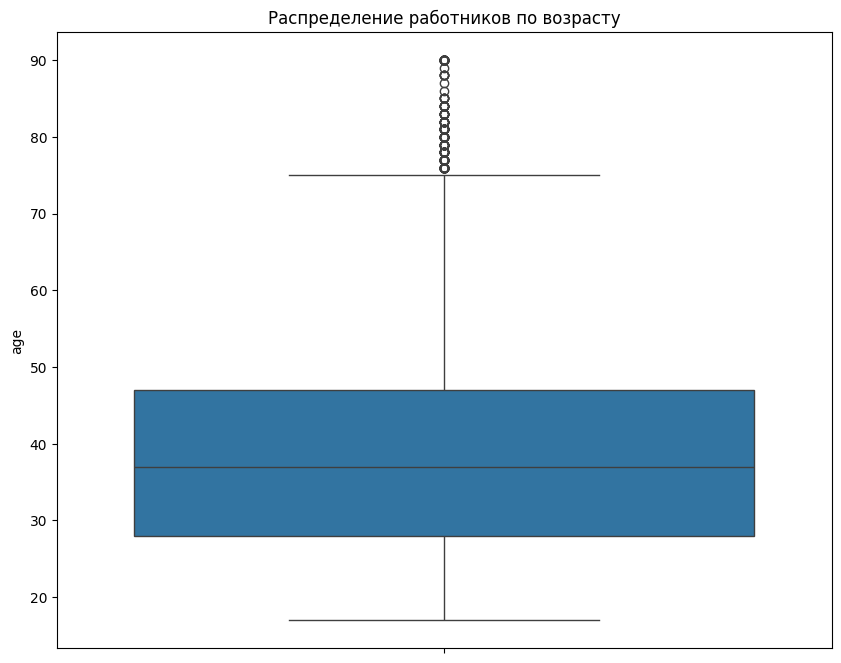

In [ ]:
#Построим боксплот, чтобы посмотреть на распределение по возрастам у работников
plt.figure(figsize=(10, 8))
sns.boxplot(df['age']).set(title='Распределение работников по возрасту')

## Преобразование признаков, обучение моделей

In [ ]:
#Выберем признаки для обучения моделей
data = df[['age','race','gender','workclass','occupation','education',
           'hours-per-week','native-country','marital-status','relationship','income']]
data

,age,race,gender,workclass,occupation,education,hours-per-week,native-country,marital-status,relationship,income
0,25,Black,Male,Private,Machine-op-inspct,11th,40,United-States,Never-married,Own-child,<=50K
1,38,White,Male,Private,Farming-fishing,HS-grad,50,United-States,Married-civ-spouse,Husband,<=50K
2,28,White,Male,Local-gov,Protective-serv,Assoc-acdm,40,United-States,Married-civ-spouse,Husband,>50K
3,44,Black,Male,Private,Machine-op-inspct,Some-college,40,United-States,Married-civ-spouse,Husband,>50K
5,34,White,Male,Private,Other-service,10th,30,United-States,Never-married,Not-in-family,<=50K
...,...,...,...,...,...,...,...,...,...,...,...
48837,27,White,Female,Private,Tech-support,Assoc-acdm,38,United-States,Married-civ-spouse,Wife,<=50K
48838,40,White,Male,Private,Machine-op-inspct,HS-grad,40,United-States,Married-civ-spouse,Husband,>50K
48839,58,White,Female,Private,Adm-clerical,HS-grad,40,United-States,Widowed,Unmarried,<=50K
48840,22,White,Male,Private,Adm-clerical,HS-grad,20,United-States,Never-married,Own-child,<=50K


In [ ]:
X = data.drop(columns='income')

In [ ]:
X.head()

,age,race,gender,workclass,occupation,education,hours-per-week,native-country,marital-status,relationship
0,25,Black,Male,Private,Machine-op-inspct,11th,40,United-States,Never-married,Own-child
1,38,White,Male,Private,Farming-fishing,HS-grad,50,United-States,Married-civ-spouse,Husband
2,28,White,Male,Local-gov,Protective-serv,Assoc-acdm,40,United-States,Married-civ-spouse,Husband
3,44,Black,Male,Private,Machine-op-inspct,Some-college,40,United-States,Married-civ-spouse,Husband
5,34,White,Male,Private,Other-service,10th,30,United-States,Never-married,Not-in-family


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
le.fit(data['income'])

LabelEncoder()

In [ ]:
y = pd.Series(data = le.transform(df['income']))
y.head()

,0
0,0
1,0
2,1
3,1
4,0


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [ ]:
cat_ = ['race','gender','workclass','occupation','education','native-country','marital-status','relationship']
num_ = ['age','hours-per-week']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first', sparse_output=False), cat_),
        ('num', StandardScaler(), num_)])

In [ ]:
df_encoded = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
X = pd.DataFrame(df_encoded, columns=feature_names)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

model = LogisticRegression(max_iter=10000, random_state=42)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [ ]:
#Обучаем модель
model.fit(X_train, y_train)

In [ ]:
model.score(X_train, y_train)

0.8316057163391105

In [ ]:
model.score(X_test, y_test)

0.8334991708126036

Модель показала хорошую (но не идеальную) accuracy


In [ ]:
#SVM
from sklearn.svm import SVC
clf = SVC()
clf.fit(X_train, y_train)

SVC()

In [ ]:
clf.score(X_train, y_train)

0.8408933853000525

In [ ]:
clf.score(X_test, y_test)

0.8383637368711996